<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week%204/Tugas_1C_TFIDF_Artikel_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tugas 1C - TF-IDF pada Artikel Berita

In [1]:
# 1. Setup & Imports
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

nltk.download('punkt')
nltk.download('punkt_tab')

print('All libraries loaded successfully.')

All libraries loaded successfully.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# 2. Input Artikel

isi_artikel = """Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus dioptimalkan melalui strategi investasi yang tepat di seluruh lini bisnis perusahaan.
Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaan dari pemerintah untuk mengambil alih 11 Wilayah Kerja Migas terminasi yang sebelumnya dikelola operator lain.
Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina Hulu Rokan maka kontribusi Pertamina Group akan meningkat signifikan terhadap produksi migas nasional.
Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi sebesar US$2,41 miliar atau 51%. Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, Pertamina kembali menganggarkan Capital Expenditure (Capex) sebesar US$10,7 miliar.
Langkah ini merupakan upaya perseroan untuk menjaga kedaulatan energi nasional dengan meningkatkan produksi minyak dan gas serta mendukung pemerintah mewujudkan produksi 1 juta barel.
Di sektor pengolahan, kata Fajriyah, anggaran investasi Pertamina juga diperuntukkan untuk membangun infrastruktur pengolahan 4 Refinery Development Master Plan (RDMP) dan 1 Grass Root Refinery (GRR) yang akan terintegrasi dengan kilang Petrokimia.
Sebagai kelanjutan dari implementasi program Biodiesel yang dijalankan sejak 2006, Pertamina juga berkomitmen mengembangkan Biofuel atau Biodiesel 100% dengan mempercepat penyelesaian proyek Biorefinery di 3 lokasi yakni kilang Cilacap, Dumai dan Plaju untuk memenuhi kebutuhan Biodiesel dengan mengolah sumber energi dari kelapa sawit yang melimpah di dalam negeri.
Melalui investasi pembangunan kilang, Indonesia dapat mewujudkan swasembada atau kemandirian energi yang sangat diperlukan di masa depan.
Lalu di sektor hilir, Pertamina juga terus mengembangkan infrastruktur penyaluran BBM, LPG, dan Gas. Saat ini, Pertamina sedang menuntaskan 14 lokasi Terminal BBM dan 4 lokasi Terminal LPG di Indonesia Timur.
Untuk mendorong upaya konversi energi bagi pembangkit listrik PLN, Pertamina juga membangun infrastruktur LNG di 56 titik.
Mengantisipasi era transisi energi, Pertamina terus mengembangkan PLTP, PLTS atau PLTGU untuk ketahanan energi nasional.
Anggaran investasi untuk seluruh proyek tersebut bersumber dari internal ekuitas perusahaan maupun pembiayaan eksternal dalam bentuk pinjaman loan, global bond atau pendanaan proyek/project financing.
Dari keseluruhan proyek, yakni 14 Proyek Strategis Nasional dan 300 proyek investasi lainnya di sektor hulu, hilir, dan energi bersih terbarukan, Pertamina memerlukan sekitar US$92 miliar sepanjang 2020-2024.
Melalui proyek dan pemanfaatan dana yang produktif ini, Pertamina dapat meningkatkan pendapatan perusahaan yang secara bertahap digunakan untuk membayar pinjaman.
Dalam rangka pengelolaan pinjaman, lanjut Fajriyah, Pertamina menjalankan beberapa strategi, di antaranya: disiplin pembentukan sinking fund, buyback global bond/liability management, cash management, akselerasi receivables collection antar perusahaan, serta disiplin monitoring hasil investasi.
Dengan strategi tersebut, perusahaan mampu merealisasikan kemampuan pembayaran obligasi yang jatuh tempo pada tahun 2021 sebesar US$391 juta. Sebelumnya tahun 2020, Pertamina juga telah melunasi tiga corporate loan dengan total mencapai US$549,4 juta.
Pada tahun 2020, Pertamina juga terbukti berhasil mencatat rasio utang yang terjaga dengan baik dan masih kompetitif di antara perusahaan migas nasional maupun internasional lainnya.
Tiga lembaga pemeringkat internasional yaitu Moody's, S&P dan Fitch menetapkan Pertamina pada peringkat investment grade masing-masing pada level Baa2, BBB, dan BBB.
Kami melakukan upaya untuk tetap mempertahankan rasio utang dalam kontrol yang wajar sebagai perusahaan yang sehat. Debt to EBITDA tetap kita jaga, dan seluruh aspek keuangan juga dimonitor oleh KBUMN sebagai Pemegang Saham.
"""

print("Panjang artikel:", len(isi_artikel), "karakter")

Panjang artikel: 3900 karakter


In [3]:
# 3. Tokenisasi Kalimat

daftar_kalimat = sent_tokenize(isi_artikel)

print("Jumlah kalimat:", len(daftar_kalimat))
print("\nContoh 5 kalimat pertama:")
for i, kal in enumerate(daftar_kalimat[:5]):
    print(f"[{i}] {kal}")

Jumlah kalimat: 23

Contoh 5 kalimat pertama:
[0] Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus dioptimalkan melalui strategi investasi yang tepat di seluruh lini bisnis perusahaan.
[1] Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaan dari pemerintah untuk mengambil alih 11 Wilayah Kerja Migas terminasi yang sebelumnya dikelola operator lain.
[2] Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina Hulu Rokan maka kontribusi Pertamina Group akan meningkat signifikan terhadap produksi migas nasional.
[3] Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi sebesar US$2,41 miliar atau 51%.
[4] Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, Pertamina kembali menganggarkan Capital Expenditure (Capex) sebesar US$10,7 miliar.


In [4]:
# 4. Preprocessing

stopword_id = {
    'dan', 'di', 'ke', 'dari', 'yang', 'untuk', 'pada', 'dengan', 'juga', 'atau',
    'ini', 'itu', 'dalam', 'oleh', 'sebagai', 'akan', 'telah', 'lebih', 'bagi',
    'yakni', 'agar', 'saat', 'masih', 'terus', 'melalui', 'serta', 'hingga',
    'karena', 'antara', 'adalah', 'kita', 'dapat', 'maupun', 'sejak', 'lainnya',
    'seluruh', 'tetap', 'lain', 'sangat', 'tahun', 'kata', 'para'
}

def bersihkan_kalimat(teks):
    teks = teks.lower()
    teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    kata = teks.split()
    kata = [k for k in kata if k not in stopword_id and len(k) > 2]
    return ' '.join(kata)

kalimat_bersih = [bersihkan_kalimat(k) for k in daftar_kalimat]

print("Contoh sebelum dan sesudah preprocessing:")
print(f"SEBELUM :", daftar_kalimat[0])
print(f"SESUDAH :", kalimat_bersih[0])

Contoh sebelum dan sesudah preprocessing:
SEBELUM : Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus dioptimalkan melalui strategi investasi yang tepat di seluruh lini bisnis perusahaan.
SESUDAH : upaya pertamina persero menjalankan perannya pengelola energi nasional dioptimalkan strategi investasi tepat lini bisnis perusahaan


In [5]:
# 5. Bag of Words

pembuat_bow = CountVectorizer()
matriks_bow = pembuat_bow.fit_transform(kalimat_bersih)

fitur_kata = pembuat_bow.get_feature_names_out()
frekuensi_kata = np.asarray(matriks_bow.sum(axis=0)).flatten()

print("Ukuran matriks BoW:", matriks_bow.shape)
print("Jumlah kosakata unik:", len(fitur_kata))

top15_bow = frekuensi_kata.argsort()[::-1][:15]

print("\nTop 15 kata (BoW - frekuensi mentah):")
for idx in top15_bow:
    print(f"{fitur_kata[idx]:20s} -> {int(frekuensi_kata[idx])}")

Ukuran matriks BoW: (23, 235)
Jumlah kosakata unik: 235

Top 15 kata (BoW - frekuensi mentah):
pertamina            -> 17
energi               -> 8
proyek               -> 7
investasi            -> 7
perusahaan           -> 7
nasional             -> 6
sektor               -> 5
upaya                -> 4
hulu                 -> 4
sebesar              -> 4
miliar               -> 4
produksi             -> 3
mengembangkan        -> 3
biodiesel            -> 3
infrastruktur        -> 3


In [6]:
# 6. TF-IDF

transformer_tfidf = TfidfTransformer()
matriks_tfidf = transformer_tfidf.fit_transform(matriks_bow)

rata_rata_tfidf = np.asarray(matriks_tfidf.mean(axis=0)).flatten()
top15_tfidf = rata_rata_tfidf.argsort()[::-1][:15]

print("Ukuran matriks TF-IDF:", matriks_tfidf.shape)

print("\nTop 15 kata (TF-IDF - rata-rata bobot):")
for idx in top15_tfidf:
    print(f"{fitur_kata[idx]:20s} -> {rata_rata_tfidf[idx]:.4f}")

Ukuran matriks TF-IDF: (23, 235)

Top 15 kata (TF-IDF - rata-rata bobot):
pertamina            -> 0.0791
energi               -> 0.0600
proyek               -> 0.0557
perusahaan           -> 0.0530
investasi            -> 0.0484
nasional             -> 0.0471
sebesar              -> 0.0437
sektor               -> 0.0423
miliar               -> 0.0416
upaya                -> 0.0394
hulu                 -> 0.0343
juta                 -> 0.0327
infrastruktur        -> 0.0318
mengembangkan        -> 0.0305
migas                -> 0.0287


In [7]:
print(len(fitur_kata))
print(len(frekuensi_kata))
print(len(rata_rata_tfidf))

235
235
235


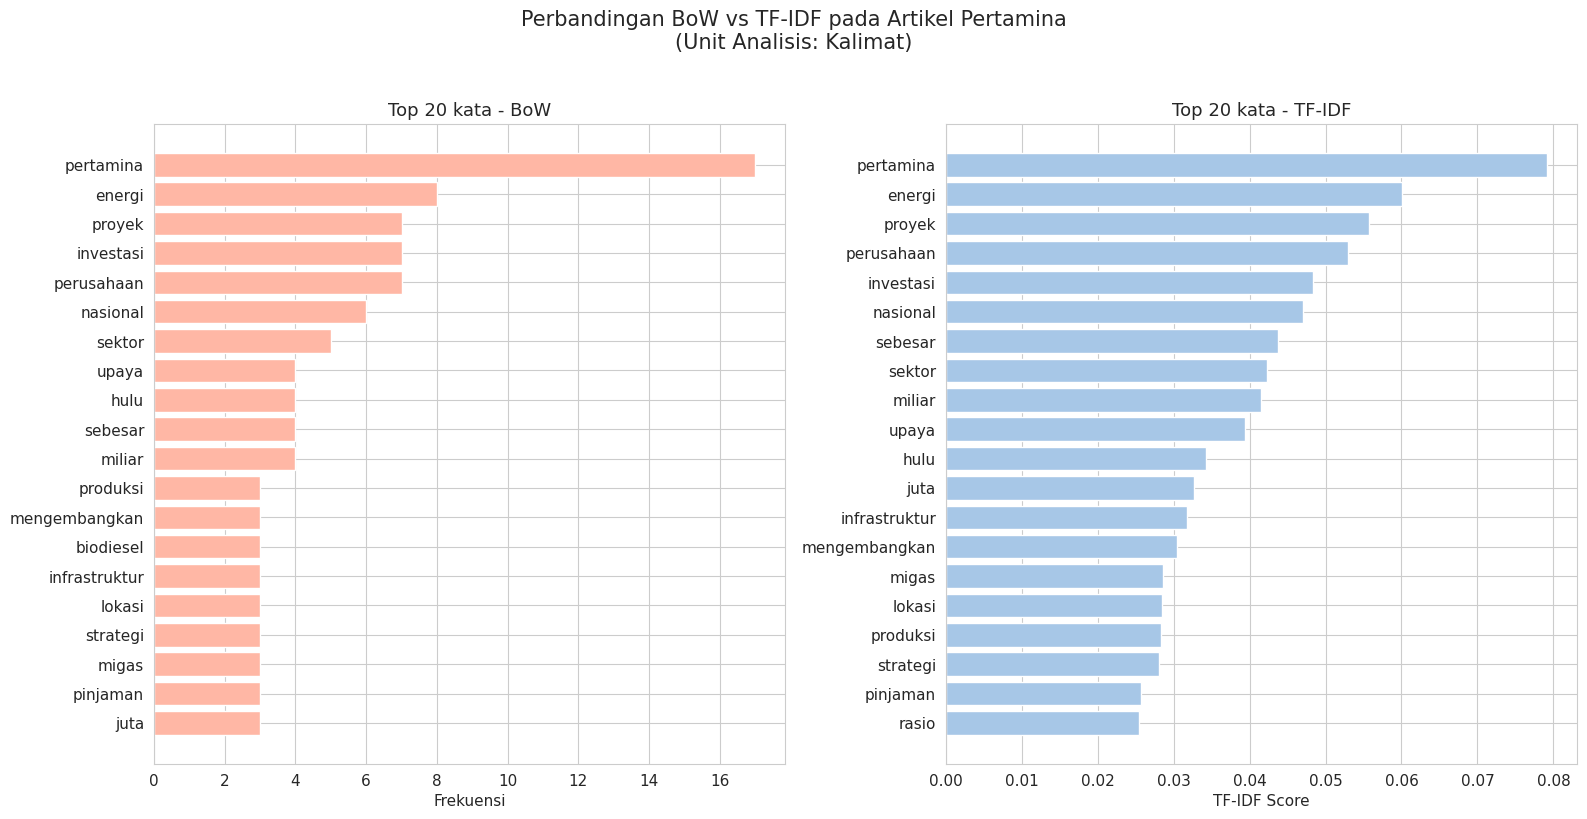

In [8]:
# 7. Perbandingan BoW vs TF-IDF

top20_bow = frekuensi_kata.argsort()[::-1][:20]
top20_tfidf = rata_rata_tfidf.argsort()[::-1][:20]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# BoW - peach
kata_bow = [fitur_kata[i] for i in top20_bow]
nilai_bow = [int(frekuensi_kata[i]) for i in top20_bow]
ax[0].barh(kata_bow[::-1], nilai_bow[::-1], color='#FFB7A5', edgecolor='white')
ax[0].set_title('Top 20 kata - BoW', fontsize=13)
ax[0].set_xlabel('Frekuensi')

# TF-IDF - biru muda
kata_tfidf = [fitur_kata[i] for i in top20_tfidf]
nilai_tfidf = [rata_rata_tfidf[i] for i in top20_tfidf]
ax[1].barh(kata_tfidf[::-1], nilai_tfidf[::-1], color='#A7C7E7', edgecolor='white')
ax[1].set_title('Top 20 kata - TF-IDF', fontsize=13)
ax[1].set_xlabel('TF-IDF Score')

plt.suptitle('Perbandingan BoW vs TF-IDF pada Artikel Pertamina\n(Unit Analisis: Kalimat)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# 8. Tabel Perbandingan BoW vs TF-IDF

print(f'{"Rank":>4}  {"BoW (kata)":20s} {"Freq":>5}  |  {"TF-IDF (kata)":20s} {"Score":>8}')
print('-' * 72)

for rank in range(15):
    idx_b = top20_bow[rank]
    idx_t = top20_tfidf[rank]
    print(f'{rank+1:>4}  {fitur_kata[idx_b]:20s} {int(frekuensi_kata[idx_b]):>5}  |  {fitur_kata[idx_t]:20s} {rata_rata_tfidf[idx_t]:>8.4f}')

Rank  BoW (kata)            Freq  |  TF-IDF (kata)           Score
------------------------------------------------------------------------
   1  pertamina               17  |  pertamina              0.0791
   2  energi                   8  |  energi                 0.0600
   3  proyek                   7  |  proyek                 0.0557
   4  investasi                7  |  perusahaan             0.0530
   5  perusahaan               7  |  investasi              0.0484
   6  nasional                 6  |  nasional               0.0471
   7  sektor                   5  |  sebesar                0.0437
   8  upaya                    4  |  sektor                 0.0423
   9  hulu                     4  |  miliar                 0.0416
  10  sebesar                  4  |  upaya                  0.0394
  11  miliar                   4  |  hulu                   0.0343
  12  produksi                 3  |  juta                   0.0327
  13  mengembangkan            3  |  infrastruktur      

In [10]:
# 9. Analisis per Kalimat
# Menampilkan kata terpenting di tiap kalimat berdasarkan TF-IDF

print('Kata terpenting per kalimat (TF-IDF):')
print('=' * 90)

for i in range(min(10, len(daftar_kalimat))):
    vektor = np.asarray(matriks_tfidf[i].todense()).flatten()
    top3_idx = vektor.argsort()[::-1][:3]
    keyword = ', '.join([f'{fitur_kata[idx]} ({vektor[idx]:.3f})' for idx in top3_idx if vektor[idx] > 0])

    print(f'  [{i:2d}] {daftar_kalimat[i][:70]}...')
    print(f'       Keywords: {keyword}')
    print()

Kata terpenting per kalimat (TF-IDF):
  [ 0] Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengel...
       Keywords: tepat (0.310), pengelola (0.310), perannya (0.310)

  [ 1] Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaa...
       Keywords: wilayah (0.268), salah (0.268), terminasi (0.268)

  [ 2] Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina ...
       Keywords: rokan (0.475), terhadap (0.237), resmi (0.237)

  [ 3] Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu menda...
       Keywords: sebesar (0.499), miliar (0.499), tertinggi (0.312)

  [ 4] Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, ...
       Keywords: pertumbuhan (0.316), menganggarkan (0.316), keberlanjutan (0.316)

  [ 5] Langkah ini merupakan upaya perseroan untuk menjaga kedaulatan energi ...
       Keywords: produksi (0.442), perseroan (0.250), minyak (0.250)

  [ 6] Di sektor pengolahan, kata Fajriyah, anggara

In [11]:
# 10. TF-IDF untuk Kalimat Pertama

def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    nilai_kalimat = tfidf_matrix[sentence_index].toarray().flatten()
    df_tfidf = pd.DataFrame({
        'Feature': feature_names,
        'TF-IDF': nilai_kalimat
    })
    df_tfidf = df_tfidf[df_tfidf['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df_tfidf

tfidf_kalimat_pertama = get_tfidf_for_sentence(matriks_tfidf, 0, fitur_kata)

print("TF-IDF values for the first cleaned sentence (sorted):")
print(tfidf_kalimat_pertama)

TF-IDF values for the first cleaned sentence (sorted):
          Feature    TF-IDF
40   dioptimalkan  0.310179
101          lini  0.310179
161     pengelola  0.310179
215         tepat  0.310179
168       persero  0.310179
166      perannya  0.310179
22         bisnis  0.274090
136   menjalankan  0.274090
210      strategi  0.248484
230         upaya  0.228623
146      nasional  0.198675
69      investasi  0.186790
48         energi  0.186790
172    perusahaan  0.186790
170     pertamina  0.119699


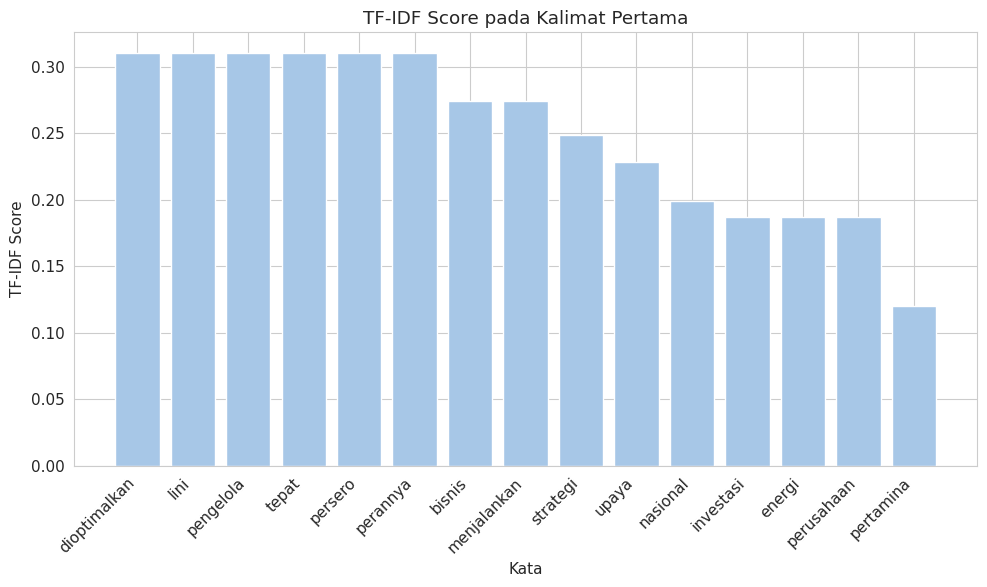

In [12]:
# 11. Visualisasi TF-IDF Kalimat Pertama

plt.figure(figsize=(10, 6))
plt.bar(tfidf_kalimat_pertama['Feature'], tfidf_kalimat_pertama['TF-IDF'], color='#A7C7E7')
plt.xlabel("Kata")
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF Score pada Kalimat Pertama")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# 12. Perhitungan Skor Rata-rata TF-IDF per Kalimat

indeks_kalimat = 0
skor_kalimat = []

print("List of Sentences:")
for i, kal in enumerate(daftar_kalimat):
    print(f"{i + 1}. {kal}")
print("\n-------------------------")

print("\nAverage TF-IDF Score for Each Sentence:")
for baris in matriks_tfidf:
    print(f"- Sentence {indeks_kalimat + 1}")
    total_skor = baris.sum()
    jumlah_kata_unik = len(baris.data)
    print("  Sum of TF-IDF scores:", total_skor)
    print("  Number of words:", jumlah_kata_unik)

    rata_skor = total_skor / jumlah_kata_unik if jumlah_kata_unik > 0 else 0
    print("  Average TF-IDF score:", rata_skor)

    skor_kalimat.append(rata_skor)
    indeks_kalimat += 1

print("\n-------------------------")
print("\nList of average TF-IDF scores for each sentence:")
print(skor_kalimat)

List of Sentences:
1. Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus dioptimalkan melalui strategi investasi yang tepat di seluruh lini bisnis perusahaan.
2. Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaan dari pemerintah untuk mengambil alih 11 Wilayah Kerja Migas terminasi yang sebelumnya dikelola operator lain.
3. Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina Hulu Rokan maka kontribusi Pertamina Group akan meningkat signifikan terhadap produksi migas nasional.
4. Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi sebesar US$2,41 miliar atau 51%.
5. Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, Pertamina kembali menganggarkan Capital Expenditure (Capex) sebesar US$10,7 miliar.
6. Langkah ini merupakan upaya perseroan untuk menjaga kedaulatan energi nasional dengan meningkatkan produksi minyak dan gas serta mendukung pemerintah

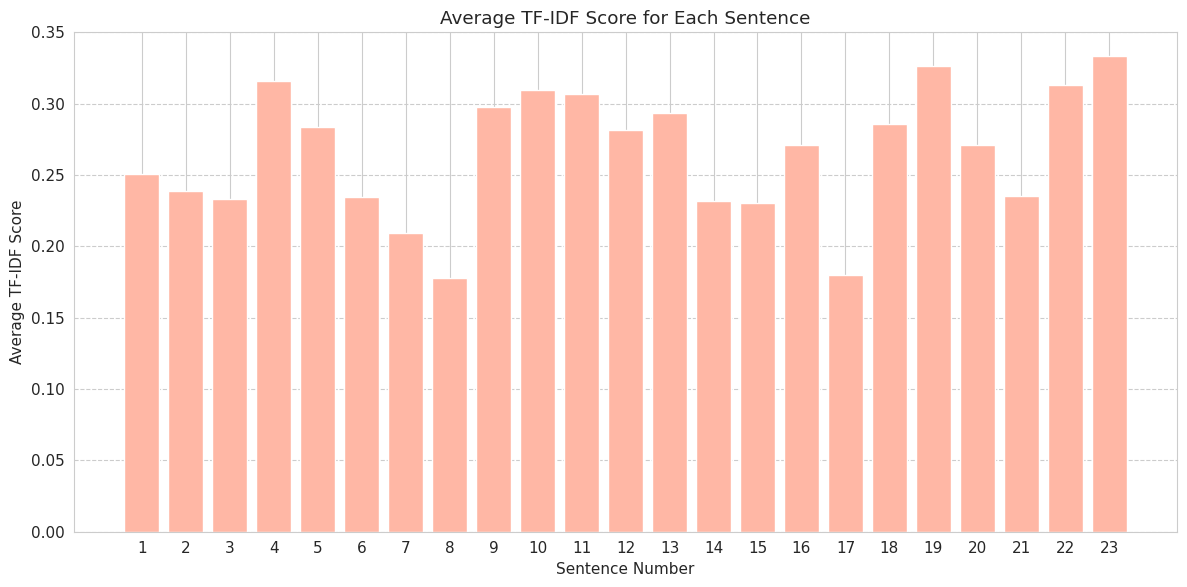


Explanation of the Histogram :
Histogram di atas menunjukkan rata-rata skor TF-IDF untuk setiap kalimat dalam artikel.
Batang yang lebih tinggi menunjukkan bahwa kalimat tersebut memiliki kata-kata yang
lebih penting dan lebih unik dibandingkan kalimat lain dalam artikel.
Sebaliknya, batang yang lebih rendah menunjukkan bahwa kalimat tersebut cenderung
berisi kata yang lebih umum atau kurang dominan dalam membedakan isi artikel.


In [14]:
# 13. Visualisasi Histogram Skor Kalimat

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(skor_kalimat) + 1), skor_kalimat, color='#FFB7A5')
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(skor_kalimat) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("\nExplanation of the Histogram :")
print("Histogram di atas menunjukkan rata-rata skor TF-IDF untuk setiap kalimat dalam artikel.")
print("Batang yang lebih tinggi menunjukkan bahwa kalimat tersebut memiliki kata-kata yang")
print("lebih penting dan lebih unik dibandingkan kalimat lain dalam artikel.")
print("Sebaliknya, batang yang lebih rendah menunjukkan bahwa kalimat tersebut cenderung")
print("berisi kata yang lebih umum atau kurang dominan dalam membedakan isi artikel.")

In [15]:
# 14. Menentukan Threshold

threshold = sum(skor_kalimat) / len(skor_kalimat) if skor_kalimat else 0
print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.26569796574260385


In [16]:
# 15. Mengambil Kalimat Ringkasan Berdasarkan Threshold

hasil_ringkasan = ""

print("\nSummary Sentences (above or equal to the threshold):")
for idx, nilai in enumerate(skor_kalimat):
    if nilai >= threshold:
        hasil_ringkasan += " " + daftar_kalimat[idx]
        print(f"- {daftar_kalimat[idx]}")

print("\nFinal Summary:")
print(hasil_ringkasan.strip())


Summary Sentences (above or equal to the threshold):
- Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi sebesar US$2,41 miliar atau 51%.
- Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, Pertamina kembali menganggarkan Capital Expenditure (Capex) sebesar US$10,7 miliar.
- Melalui investasi pembangunan kilang, Indonesia dapat mewujudkan swasembada atau kemandirian energi yang sangat diperlukan di masa depan.
- Lalu di sektor hilir, Pertamina juga terus mengembangkan infrastruktur penyaluran BBM, LPG, dan Gas.
- Saat ini, Pertamina sedang menuntaskan 14 lokasi Terminal BBM dan 4 lokasi Terminal LPG di Indonesia Timur.
- Untuk mendorong upaya konversi energi bagi pembangkit listrik PLN, Pertamina juga membangun infrastruktur LNG di 56 titik.
- Mengantisipasi era transisi energi, Pertamina terus mengembangkan PLTP, PLTS atau PLTGU untuk ketahanan energi nasional.
- Melalui proyek dan pemanfaatan dana yang produktif ini, Pertam

In [17]:
# 16. Menghitung TF-IDF Kata Tertentu Secara Manual
# Misalnya kata: "investasi"

semua_kalimat_bersih = []

for kal in daftar_kalimat:
    bersih = bersihkan_kalimat(kal)
    semua_kalimat_bersih.append(bersih)

def hitung_tf(term, dokumen):
    tokens = word_tokenize(dokumen.lower())
    return tokens.count(term) / len(tokens) if len(tokens) > 0 else 0

def hitung_idf(term, semua_dokumen):
    jumlah_dokumen_term = sum(1 for doc in semua_dokumen if term.lower() in word_tokenize(doc.lower()))
    if jumlah_dokumen_term > 0:
        return np.log(len(semua_dokumen) / jumlah_dokumen_term)
    else:
        return 0

skor_tfidf_manual = {}
for i, kal in enumerate(semua_kalimat_bersih):
    tf = hitung_tf("investasi", kal)
    idf = hitung_idf("investasi", semua_kalimat_bersih)
    tfidf = tf * idf
    skor_tfidf_manual[f"Sentence {i+1}"] = tfidf

print("TF-IDF Score for 'investasi' in each cleaned sentence:")
for kalimat_ke, skor in skor_tfidf_manual.items():
    print(f"{kalimat_ke}: {skor:.4f}")

overall_idf_investasi = hitung_idf("investasi", semua_kalimat_bersih)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

TF-IDF Score for 'investasi' in each cleaned sentence:
Sentence 1: 0.0793
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.1081
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0541
Sentence 8: 0.0000
Sentence 9: 0.1081
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0626
Sentence 15: 0.0661
Sentence 16: 0.0000
Sentence 17: 0.0397
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000
Sentence 21: 0.0000
Sentence 22: 0.0000
Sentence 23: 0.0000

Overall IDF for 'investasi': 1.1896


In [18]:
# 17. TF-IDF Kata "investasi" dengan Matriks TF-IDF

try:
    idx_investasi = list(fitur_kata).index("investasi")
    print("TF-IDF Score for 'investasi' using TfidfTransformer:")
    for i in range(matriks_tfidf.shape[0]):
        nilai = matriks_tfidf[i, idx_investasi]
        print(f"Sentence {i+1}: {nilai:.4f}")
except ValueError:
    print("'investasi' tidak ditemukan dalam vocabulary.")

TF-IDF Score for 'investasi' using TfidfTransformer:
Sentence 1: 0.1868
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.1877
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.1267
Sentence 8: 0.0000
Sentence 9: 0.2015
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.1485
Sentence 15: 0.1524
Sentence 16: 0.0000
Sentence 17: 0.1094
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000
Sentence 21: 0.0000
Sentence 22: 0.0000
Sentence 23: 0.0000


##Kesimpulan

* Bag of Words (BoW) menunjukkan kata-kata yang paling sering muncul
dalam artikel, seperti kata yang berkaitan dengan Pertamina, energi, investasi, dan proyek.
Namun, metode ini masih menekankan frekuensi kemunculan kata sehingga kata yang sering muncul
belum tentu menjadi kata yang paling informatif.
* TF-IDF memberikan bobot yang lebih tinggi pada kata-kata yang lebih spesifik
dan relevan dalam kalimat tertentu. Dalam hal ini TF-IDF lebih efektif untuk menyoroti
informasi penting dibandingkan BoW.
* Analisis per kalimat menunjukkan bahwa setiap kalimat memiliki fokus informasi yang berbeda,
misalnya tentang sektor hulu, pembangunan kilang, distribusi energi, kebutuhan investasi,
hingga strategi pengelolaan pinjaman dan kesehatan keuangan perusahaan.
* Hasil analisis per kalimat menunjukkan bahwa informasi penting tersebar pada beberapa bagian
yang membahas investasi, infrastruktur energi, serta strategi keuangan perusahaan. Kalimat-kalimat
tersebut kemudian terpilih sebagai ringkasan karena memiliki kontribusi informasi yang lebih
tinggi dibandingkan kalimat lainnya.


